# Used Car Price Prediction
### Linear Regression & Neural Network Models

This notebook predicts used car prices using two machine learning approaches:
- **Linear Regression** — interpretable baseline model
- **Neural Network** — deep learning model for capturing non-linear patterns

**Features used:** Year, Manufacturer, Model, Condition, Cylinders, Fuel, Odometer, Title Status, Transmission, Drive, Type, Paint Color

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("All libraries loaded successfully!")

TensorFlow version: 2.19.0
Pandas version: 2.2.2
All libraries loaded successfully!


## 2. Load & Inspect Data

In [ ]:
df = pd.read_csv('parsedData.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
df.head(10)

Dataset shape: (426880, 14)

Column names: ['id', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color']


,id,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color
0,7222695916,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7218891961,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7221797935,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7222270760,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7210384030,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,7222379453,1600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7221952215,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7220195662,15995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,7209064557,5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,7219485069,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning & Preprocessing

In [ ]:
df_clean = df.copy()

# Remove ID
df_clean = df_clean.drop(columns=['id'])

# Filter prices
# Remove $0 prices and extreme outliers
df_clean = df_clean[df_clean['price'] > 500]
df_clean = df_clean[df_clean['price'] < 150_000]

# Filter years
df_clean = df_clean[df_clean['year'].notna()]
df_clean = df_clean[df_clean['year'] >= 1980]
df_clean = df_clean[df_clean['year'] <= 2024]

# Filter odometer
df_clean = df_clean[df_clean['odometer'].notna()]
df_clean = df_clean[df_clean['odometer'] > 0]
df_clean = df_clean[df_clean['odometer'] < 500_000]

# standardize cylindres
def parse_cylinders(val):
    if pd.isna(val): return np.nan
    val = str(val).strip().lower()
    if val == 'other': return np.nan
    try:
        return float(val.split()[0])
    except:
        return np.nan

df_clean['cylinders'] = df_clean['cylinders'].apply(parse_cylinders)

# Get Car Age
df_clean['car_age'] = 2024 - df_clean['year']

# lowercase col names
cat_cols = ['manufacturer', 'model', 'condition', 'fuel',
            'title_status', 'transmission', 'drive', 'type', 'paint_color']
for col in cat_cols:
    df_clean[col] = df_clean[col].astype(str).str.lower().str.strip()
    df_clean[col] = df_clean[col].replace('nan', np.nan)

print(f"\nPrice range: ${df_clean['price'].min():,.0f} — ${df_clean['price'].max():,.0f}")
print(f"Median price: ${df_clean['price'].median():,.0f}")

Rows after cleaning: 370,585 (removed 56,295 rows)

Price range: $501 — $149,998
Median price: $15,988


## 4. Exploratory Data Analysis

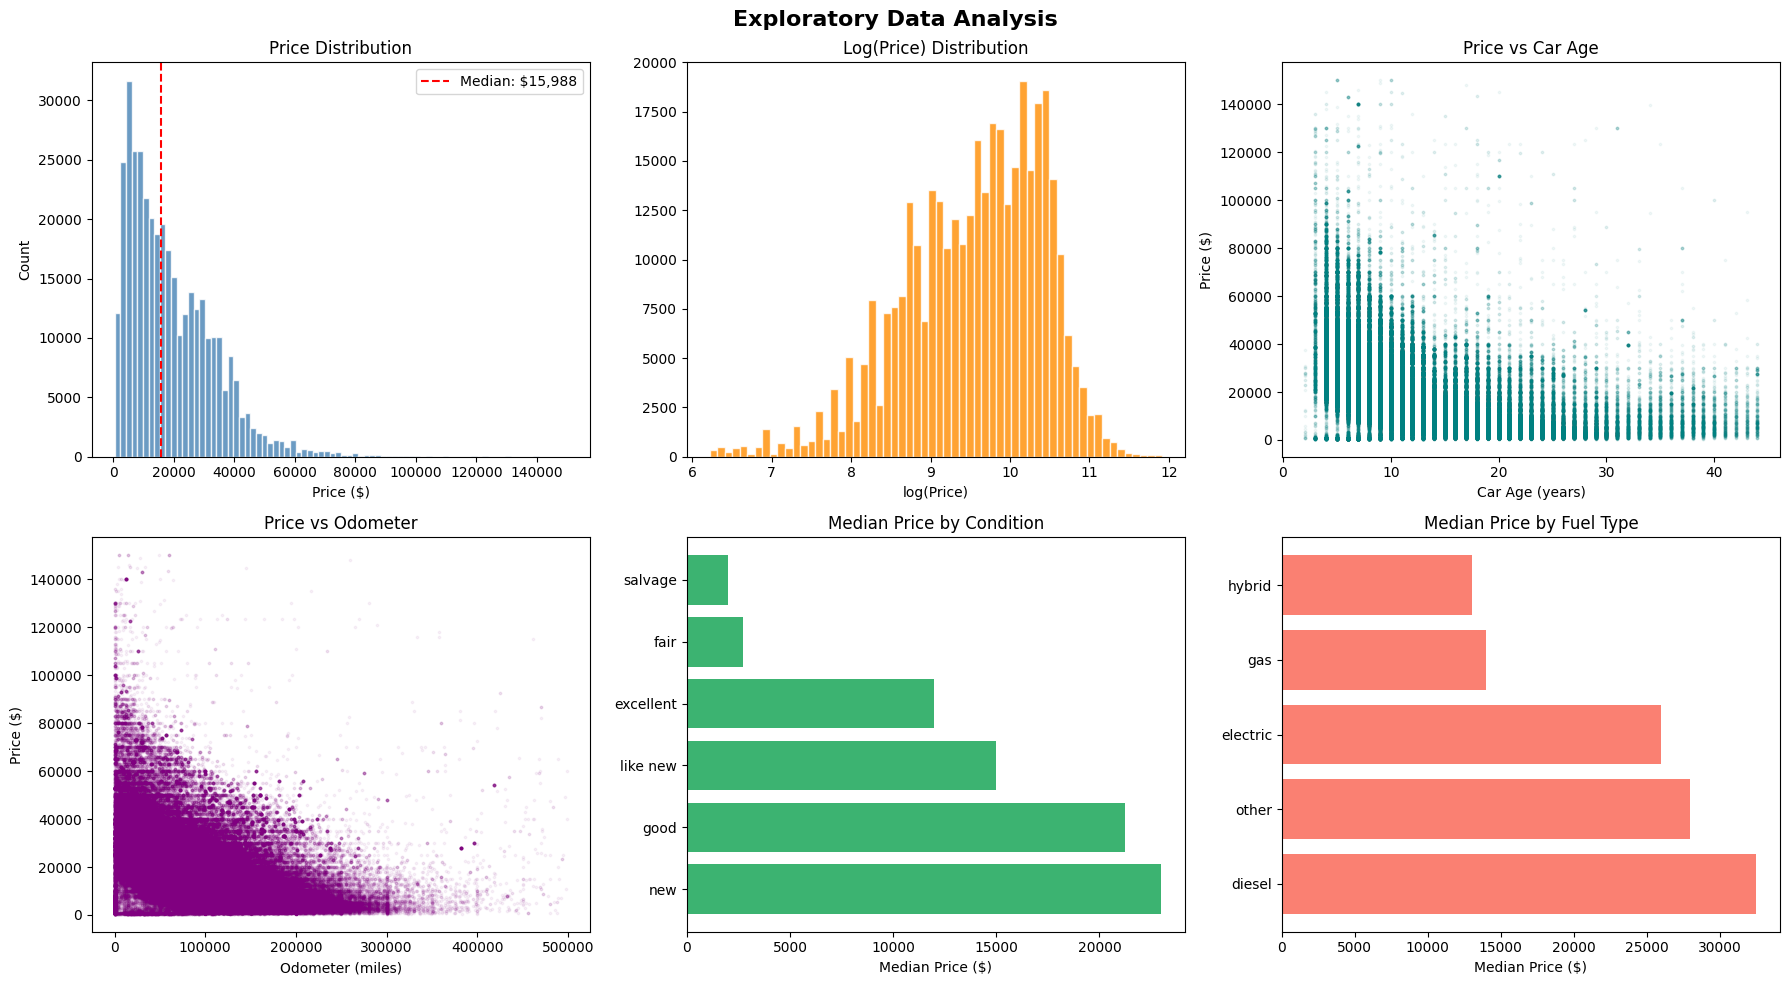

EDA plots saved to eda_plots.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Price distribution
axes[0, 0].hist(df_clean['price'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].axvline(df_clean['price'].median(), color='red', linestyle='--', label=f"Median: ${df_clean['price'].median():,.0f}")
axes[0, 0].legend()

# Log price distribution
axes[0, 1].hist(np.log1p(df_clean['price']), bins=60, color='darkorange', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Log(Price) Distribution')
axes[0, 1].set_xlabel('log(Price)')

# Price vs Car Age
axes[0, 2].scatter(df_clean['car_age'], df_clean['price'], alpha=0.05, s=3, color='teal')
axes[0, 2].set_title('Price vs Car Age')
axes[0, 2].set_xlabel('Car Age (years)')
axes[0, 2].set_ylabel('Price ($)')

# Price vs Odometer
axes[1, 0].scatter(df_clean['odometer'], df_clean['price'], alpha=0.05, s=3, color='purple')
axes[1, 0].set_title('Price vs Odometer')
axes[1, 0].set_xlabel('Odometer (miles)')
axes[1, 0].set_ylabel('Price ($)')

# Avg price by condition
cond_price = df_clean.groupby('condition')['price'].median().dropna().sort_values(ascending=False)
axes[1, 1].barh(cond_price.index, cond_price.values, color='mediumseagreen')
axes[1, 1].set_title('Median Price by Condition')
axes[1, 1].set_xlabel('Median Price ($)')

# Avg price by fuel type
fuel_price = df_clean.groupby('fuel')['price'].median().dropna().sort_values(ascending=False).head(8)
axes[1, 2].barh(fuel_price.index, fuel_price.values, color='salmon')
axes[1, 2].set_title('Median Price by Fuel Type')
axes[1, 2].set_xlabel('Median Price ($)')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()

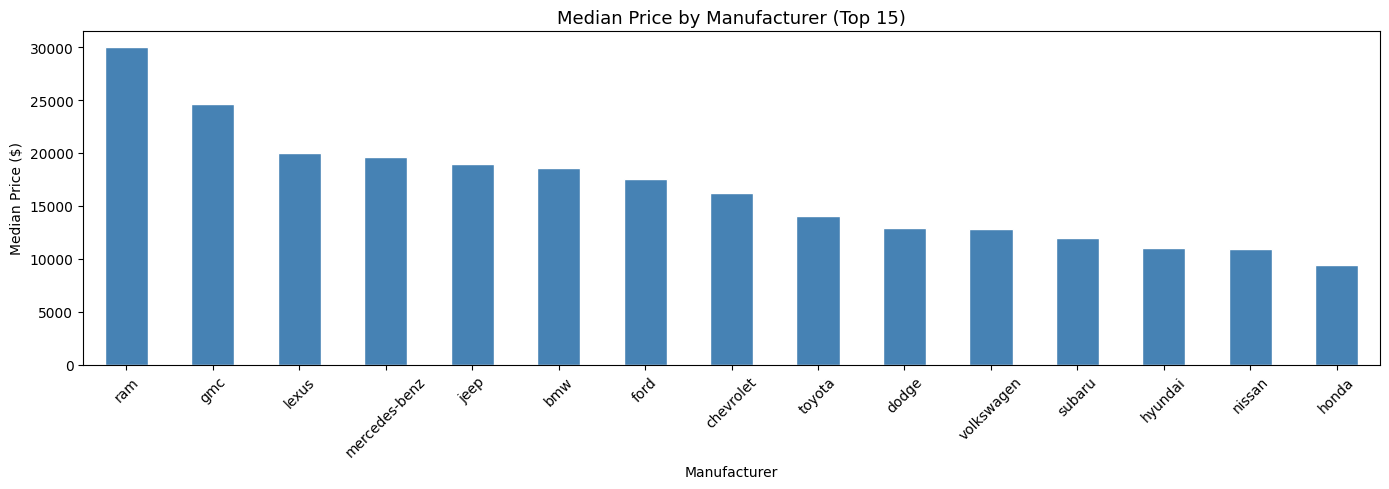

In [ ]:
# Top 15 manufacturers by count & median price
top_manufacturers = df_clean['manufacturer'].value_counts().head(15).index
mfr_data = df_clean[df_clean['manufacturer'].isin(top_manufacturers)]

fig, ax = plt.subplots(figsize=(14, 5))
mfr_price = mfr_data.groupby('manufacturer')['price'].median().sort_values(ascending=False)
mfr_price.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Median Price by Manufacturer (Top 15)', fontsize=13)
ax.set_xlabel('Manufacturer')
ax.set_ylabel('Median Price ($)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('manufacturer_prices.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Feature Engineering & Train/Test Split

In [ ]:
# Define features
NUMERIC_FEATURES = ['year', 'car_age', 'odometer', 'cylinders']
CATEGORICAL_FEATURES = ['manufacturer', 'condition', 'fuel',
                        'title_status', 'transmission', 'drive',
                        'type', 'paint_color']
# drop car model

TARGET = 'price'

# Use log(price) as target — improves model performance by reducing skewness
df_clean['log_price'] = np.log1p(df_clean[TARGET])

feature_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES
X = df_clean[feature_cols].copy()
y = df_clean['log_price'].copy()

# Train/Validation/Test split: 70% / 15% / 15%
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Training samples:   {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Test samples:       {len(X_test):,}")

Training samples:   259,409
Validation samples: 55,588
Test samples:       55,588


In [ ]:
# Build preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

# Fit on training data only
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

print(f"Processed feature matrix shape: {X_train_proc.shape}")
print(f"  → {X_train_proc.shape[1]} total features after one-hot encoding")

Processed feature matrix shape: (259409, 102)
  → 102 total features after one-hot encoding


## 6. Model 1 — Linear Regression (Ridge)

In [ ]:
# Ridge regression adds L2 regularization to handle multicollinearity
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_proc, y_train)

# Predictions (convert log predictions back to dollar prices)
y_pred_log_lr = ridge.predict(X_test_proc)
y_pred_lr     = np.expm1(y_pred_log_lr)
y_true        = np.expm1(y_test)

# Evaluation metrics
mae_lr   = mean_absolute_error(y_true, y_pred_lr)
rmse_lr  = np.sqrt(mean_squared_error(y_true, y_pred_lr))
r2_lr    = r2_score(y_test, y_pred_log_lr)
mape_lr  = np.mean(np.abs((y_true - y_pred_lr) / y_true)) * 100

print("=== Linear Regression (Ridge) — Test Set Results ===")
print(f"  MAE:   ${mae_lr:,.0f}")
print(f"  RMSE:  ${rmse_lr:,.0f}")
print(f"  R²:    {r2_lr:.4f}")
print(f"  MAPE:  {mape_lr:.2f}%")

=== Linear Regression (Ridge) — Test Set Results ===
  MAE:   $5,151
  RMSE:  $8,524
  R²:    0.6602
  MAPE:  57.83%


## 7. Model 2 — Neural Network

In [ ]:
input_dim = X_train_proc.shape[1]

def build_neural_network(input_dim, learning_rate=1e-3):

    inputs = keras.Input(shape=(input_dim,), name='features')

    x = layers.Dense(512, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(64, activation='relu')(x)

    output = layers.Dense(1, name='price_prediction')(x)

    model = keras.Model(inputs, output)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='huber',
        metrics=['mae']
    )
    return model

nn_model = build_neural_network(input_dim)
nn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 102)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        52,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ price_prediction (Dense)        │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 228,865 (894.00 KB)

 Trainable params: 227,073 (887.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
# Callbacks for training
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_mae',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

# Train the model
history = nn_model.fit(
    X_train_proc, y_train,
    validation_data=(X_val_proc, y_val),
    epochs=100,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")

Epoch 1/100
507/507 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - loss: 0.5611 - mae: 0.9076 - val_loss: 0.1124 - val_mae: 0.3515 - learning_rate: 0.0010
Epoch 2/100
507/507 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - loss: 0.2207 - mae: 0.5339 - val_loss: 0.1102 - val_mae: 0.3519 - learning_rate: 0.0010
Epoch 3/100
507/507 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - loss: 0.1952 - mae: 0.4956 - val_loss: 0.0980 - val_mae: 0.3194 - learning_rate: 0.0010
Epoch 4/100
507/507 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - loss: 0.1692 - mae: 0.4550 - val_loss: 0.0922 - val_mae: 0.2977 - learning_rate: 0.0010
Epoch 5/100
507/507 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - loss: 0.1471 - mae: 0.4177 - val_loss: 0.0950 - val_mae: 0.3196 - learning_rate: 0.0010
Epoch 6/100
507/507 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - loss: 0.1265 - mae: 0.3793 - val_loss: 0.0939 - val_mae: 0.3098 - learning_rate: 0.0010
Epoch 7/100
507/507 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - loss: 0.1098 - mae: 0.3443 - val_loss: 0.0994 - val_mae: 0.3332 - learnin

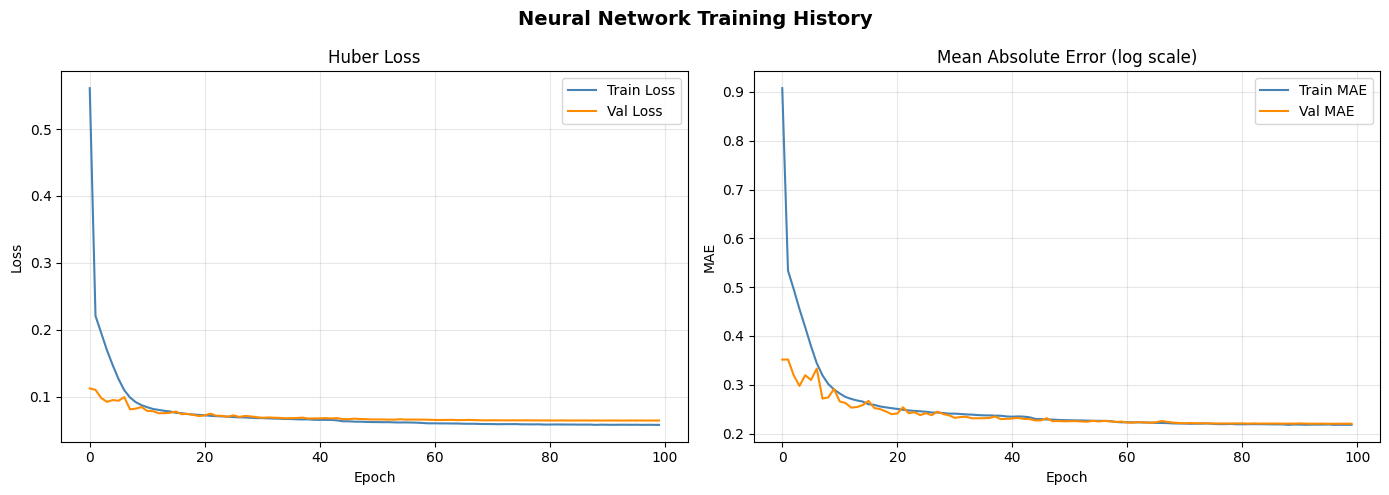

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Neural Network Training History', fontsize=14, fontweight='bold')

axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='darkorange')
axes[0].set_title('Huber Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE', color='steelblue')
axes[1].plot(history.history['val_mae'], label='Val MAE', color='darkorange')
axes[1].set_title('Mean Absolute Error (log scale)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('nn_training_history.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# Evaluate Neural Network on test set
y_pred_log_nn = nn_model.predict(X_test_proc, verbose=0).flatten()
y_pred_nn     = np.expm1(y_pred_log_nn)

mae_nn   = mean_absolute_error(y_true, y_pred_nn)
rmse_nn  = np.sqrt(mean_squared_error(y_true, y_pred_nn))
r2_nn    = r2_score(y_test, y_pred_log_nn)
mape_nn  = np.mean(np.abs((y_true - y_pred_nn) / y_true)) * 100

print("=== Neural Network — Test Set Results ===")
print(f"  MAE:   ${mae_nn:,.0f}")
print(f"  RMSE:  ${rmse_nn:,.0f}")
print(f"  R²:    {r2_nn:.4f}")
print(f"  MAPE:  {mape_nn:.2f}%")

=== Neural Network — Test Set Results ===
  MAE:   $3,151
  RMSE:  $5,862
  R²:    0.7859
  MAPE:  41.03%


## 8. Model Comparison & Diagnostics

In [ ]:
# Summary comparison table
results = pd.DataFrame({
    'Model': ['Ridge Regression', 'Neural Network'],
    'MAE ($)':  [f"${mae_lr:,.0f}",  f"${mae_nn:,.0f}"],
    'RMSE ($)': [f"${rmse_lr:,.0f}", f"${rmse_nn:,.0f}"],
    'R²':       [f"{r2_lr:.4f}",     f"{r2_nn:.4f}"],
    'MAPE (%)': [f"{mape_lr:.2f}%",  f"{mape_nn:.2f}%"]
})
print("\n====== MODEL COMPARISON ======")
print(results.to_string(index=False))


====== MODEL COMPARISON ======
           Model MAE ($) RMSE ($)     R² MAPE (%)
Ridge Regression  $5,151   $8,524 0.6602   57.83%
  Neural Network  $3,151   $5,862 0.7859   41.03%


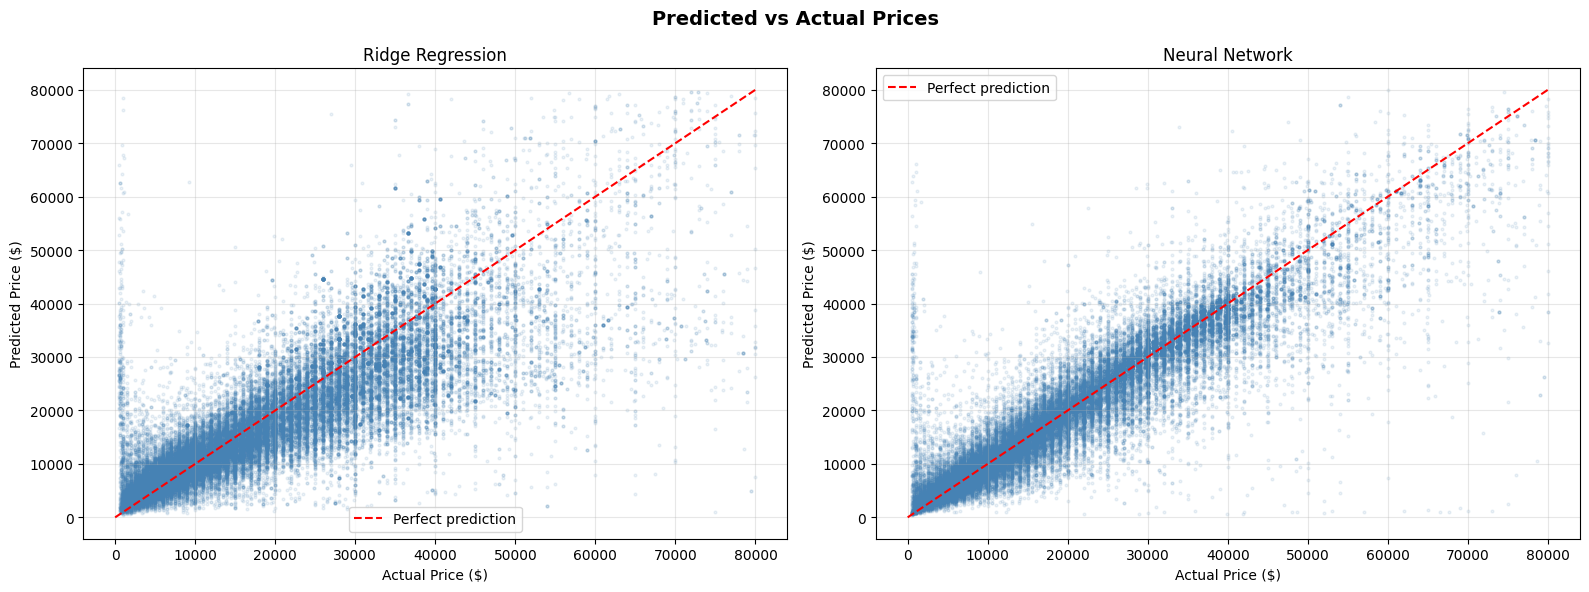

In [ ]:
# Predicted vs Actual scatter plots for both models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Predicted vs Actual Prices', fontsize=14, fontweight='bold')

price_cap = 80_000  # Zoom into the main price range for clarity

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_nn],
    ['Ridge Regression', 'Neural Network']
):
    mask = (y_true < price_cap) & (y_pred < price_cap)
    ax.scatter(y_true[mask], y_pred[mask], alpha=0.1, s=4, color='steelblue')
    ax.plot([0, price_cap], [0, price_cap], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_title(title)
    ax.set_xlabel('Actual Price ($)')
    ax.set_ylabel('Predicted Price ($)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()

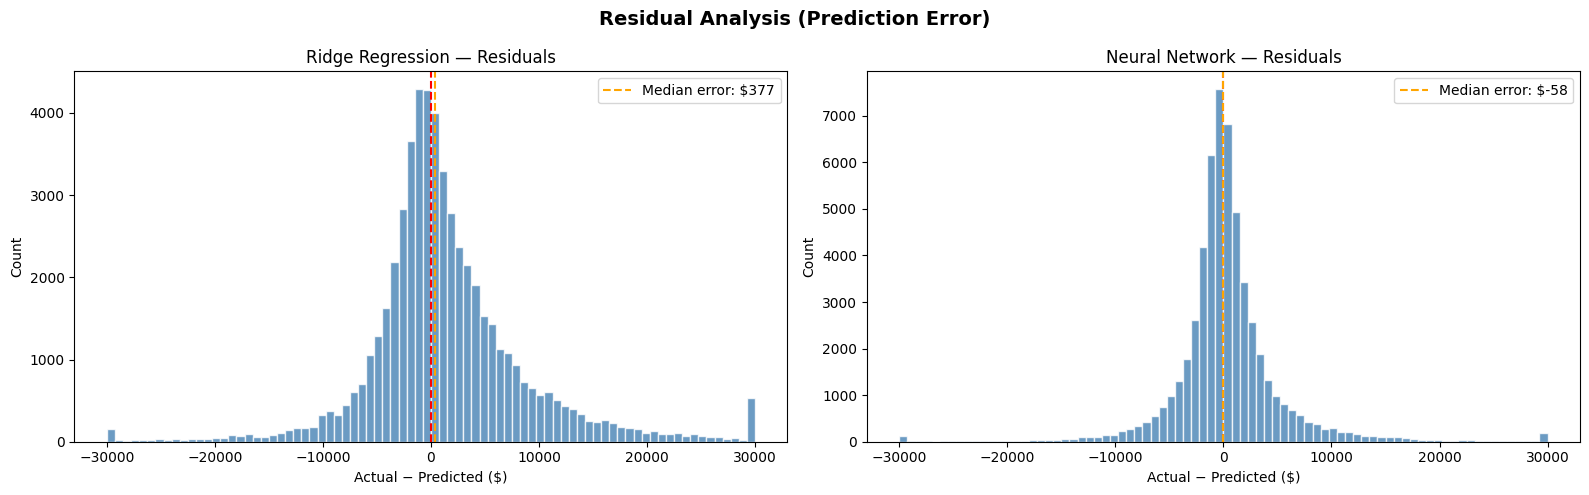

In [ ]:
# Residuals analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Residual Analysis (Prediction Error)', fontsize=14, fontweight='bold')

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_nn],
    ['Ridge Regression', 'Neural Network']
):
    residuals = y_true.values - y_pred
    residuals_clipped = np.clip(residuals, -30_000, 30_000)
    ax.hist(residuals_clipped, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
    ax.axvline(np.median(residuals), color='orange', linestyle='--', linewidth=1.5,
               label=f"Median error: ${np.median(residuals):,.0f}")
    ax.set_title(f'{title} — Residuals')
    ax.set_xlabel('Actual − Predicted ($)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('residuals.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Save Models

In [ ]:
import joblib

# Save Ridge model + preprocessor
joblib.dump(ridge, 'ridge_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')
print("Ridge model saved to ridge_model.pkl")
print("Preprocessor saved to preprocessor.pkl")

# Save Neural Network
nn_model.save('neural_network_model.keras')
print("Neural network saved to neural_network_model.keras")

print("\n=== Training Complete ===")
print(f"Ridge R²: {r2_lr:.4f} | Neural Network R²: {r2_nn:.4f}")

Ridge model saved to ridge_model.pkl
Preprocessor saved to preprocessor.pkl
Neural network saved to neural_network_model.keras

=== Training Complete ===
Ridge R²: 0.6602 | Neural Network R²: 0.7859
